<a href="https://colab.research.google.com/github/SehrishbAsghar/ASSIGNMENT/blob/main/CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset with color images(32x32)categorized in objects and animals

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

DEVICE SETUP

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device: {device}')
#automatically detects GPU vs. CPU.

Using Device: cpu


LOADING CIFAR-10 DATASET

In [4]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding = 4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
# RandomHorizontalFlip() randomly mirrors images during training
#RandomCrop(32, padding=4) randomly shifts images slightly
# these are called data augmentation. this makes model not to see exact image twice. artifically creating more training variations
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))]) #three values now because RGB
train_dataset = torchvision.datasets.CIFAR10(
    root = './data', train= True, download = True,
    transform= transform_train)
test_dataset = torchvision.datasets.CIFAR10(
    root = './data', train = False, download = True,
    transform= transform_test)


100%|██████████| 170M/170M [1:06:28<00:00, 42.7kB/s]


Example of data augmentation:
Original image: cat facing right
Augmented: cat facing left (flipped)
Also augmented: cat slightly shifted (cropped)
This is one of the most powerful tricks for improving CNN accuracy on real images.
Data Augmentation applied to training data only b/c we need consistent evaluation

In [5]:
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size= 128, shuffle= True)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=128, shuffle= False)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')
print(f'Training Samples: {len(train_dataset)}')
print(f"Test Samples: {len(test_dataset)}")


Training Samples: 50000
Test Samples: 10000


VISUALIZING DATA

Batch Shape: torch.Size([128, 3, 32, 32])


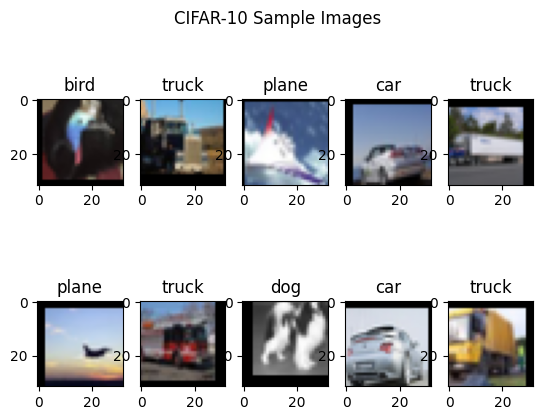

In [6]:
images, labels = next(iter(train_loader))
print(f"Batch Shape: {images.shape}")
fig, axes = plt.subplots(2,5)
for i, ax in enumerate(axes.flatten()):
  img = images[i].numpy().transpose(1,2,0) #transpose is changing the indices
  # transpose(1, 2, 0) means:"put what was at index 1 (height) first"
  #"put what was at index 2 (width) second"
  #"put what was at index 0 (channels) third"
  img = (img * 0.5) + 0.5
  ax.imshow(img)
  ax.set_title(classes[labels[i]])
  plt.suptitle("CIFAR-10 Sample Images")

BUILDING CNN

2 conv per block b/c conv1 detects simple pattern(edges) and conv2 combine those in complex patterns(corners, textures)
pool domnsamples.
Image size through the network:
32×32 (input) 32×32 (after block 1 convs) 16×16 (after pool1) 16×16 (after block 2 convs) 8×8 (after pool2)
That's why self.fc1 = nn.Linear(64 * 8 * 8, 512) — 64 channels, 8×8 spatial size

Using BatchNorm1d or 2d depends on shape of data. after fc(flattening) layers are reduced so 1d is used

In [7]:
class CIFAR10NET(nn.Module):
  def __init__(self):
    super(CIFAR10NET, self).__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size= 3, padding= 1)
    self.bn1 = nn.BatchNorm2d(32)
    self.conv2 = nn.Conv2d(32,32, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(32)
    self.pool1 = nn.MaxPool2d(2,2)
    self.drop1 = nn.Dropout(0.25)

    self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding = 1)
    self.bn3 = nn.BatchNorm2d(64)
    self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(64)
    self.pool2 = nn.MaxPool2d(2,2)
    self.drop2 = nn.Dropout(0.25)

    self.fc1 = nn.Linear(64*8*8, 512)
    self.bn5 = nn.BatchNorm1d(512)
    self.drop3 = nn.Dropout(0.5)
    self.fc2 = nn.Linear(512, 10)

    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.bn1(self.conv1(x)))
    x = self.relu(self.bn2(self.conv2(x)))
    x = self.pool1(x)
    x = self.drop1(x)

    x = self.relu(self.bn3(self.conv3(x)))
    x = self.relu(self.bn4(self.conv4(x)))
    x = self.pool2(x)
    x = self.drop2(x)

    x = x.view(x.size(0), -1)

    x = self.relu(self.bn5(self.fc1(x)))
    x = self.drop3(x)
    x = self.fc2(x)
    return x
model = CIFAR10NET().to(device)
print(model)
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

CIFAR10NET(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (bn5

TRAINING THE MODEL

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay= 1e-4)
schedular = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode= 'max', patience= 3, factor = 0.5)
#when metric plateaus(stops improving) ReduceLROnPlateau automatically reduces lr
#mode = max means schedular monitors accuracy not loss
best_acc = 0
patience = 7
patience_counter = 0
best_model_state = None
train_losses = []
test_accs = []
learning_rates = []


In [9]:
epochs = 30
for epoch in range(epochs):
  model.train()
  running_loss = 0
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  avg_loss = running_loss / len(train_loader)
  train_losses.append(avg_loss)

  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
    for images, labels in test_loader:
      images = images.to(device) #properly moves data to GPU from CPU
      labels = labels.to(device)
      outputs = model(images)
      _,predicted = torch.max(outputs, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  acc = correct / total
  test_accs.append(acc)
  current_lr = optimizer.param_groups[0]['lr'] #extracting lr values from the list of dict
  learning_rates.append(current_lr)

  print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}" f" Accuracy: {acc} LR = {current_lr}")
  schedular.step(acc)
  if acc > best_acc:
    best_acc = acc
    patience_counter = 0
    best_model_state = model.state_dict().copy() #restores the best weights .copy() gives a constant best weight
    print(f"New best: {best_acc}")
  else:
    patience_counter += 1
    print(f"No Improvement: {patience_counter}/ {patience}")
    if patience_counter >= patience:
      print(f"Early stopping at {epoch+1}")
      break


Epoch 1: Loss = 1.4402 Accuracy: 0.6265 LR = 0.001
New best: 0.6265
Epoch 2: Loss = 1.0747 Accuracy: 0.6611 LR = 0.001
New best: 0.6611
Epoch 3: Loss = 0.9497 Accuracy: 0.7399 LR = 0.001
New best: 0.7399
Epoch 4: Loss = 0.8738 Accuracy: 0.7401 LR = 0.001
New best: 0.7401
Epoch 5: Loss = 0.8228 Accuracy: 0.7508 LR = 0.001
New best: 0.7508
Epoch 6: Loss = 0.7884 Accuracy: 0.7693 LR = 0.001
New best: 0.7693
Epoch 7: Loss = 0.7525 Accuracy: 0.7772 LR = 0.001
New best: 0.7772
Epoch 8: Loss = 0.7242 Accuracy: 0.7936 LR = 0.001
New best: 0.7936
Epoch 9: Loss = 0.7086 Accuracy: 0.7985 LR = 0.001
New best: 0.7985
Epoch 10: Loss = 0.6830 Accuracy: 0.7884 LR = 0.001
No Improvement: 1/ 7
Epoch 11: Loss = 0.6632 Accuracy: 0.8065 LR = 0.001
New best: 0.8065
Epoch 12: Loss = 0.6558 Accuracy: 0.7967 LR = 0.001
No Improvement: 1/ 7
Epoch 13: Loss = 0.6337 Accuracy: 0.8061 LR = 0.001
No Improvement: 2/ 7
Epoch 14: Loss = 0.6261 Accuracy: 0.8071 LR = 0.001
New best: 0.8071
Epoch 15: Loss = 0.6099 Accurac

Best Accuracy: 0.8459


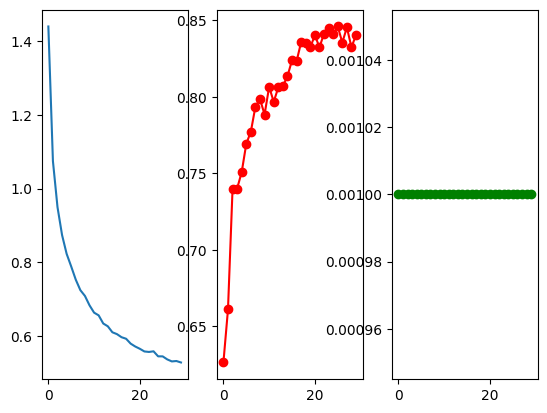

In [10]:
model.load_state_dict(best_model_state)
print(f"Best Accuracy: {best_acc}")
fig, axes = plt.subplots(1,3)
axes[0].plot(train_losses)
axes[1].plot(test_accs, 'r-o')
axes[2].plot(learning_rates, 'g-o')

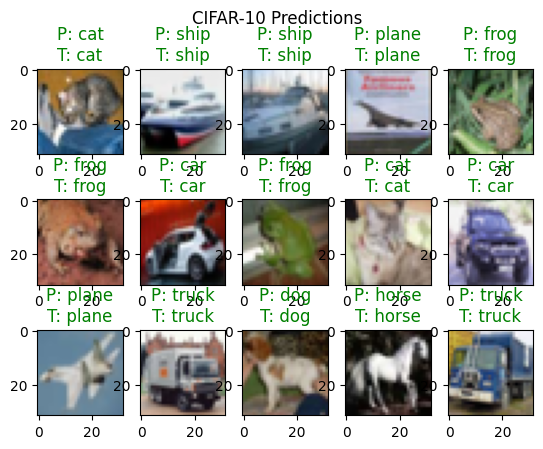

In [24]:

model.eval() #per class analysis
images, labels = next(iter(test_loader))
images_device = images.to(device)

with torch.no_grad():
  outputs = model(images_device)
  _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(3,5)
for i, ax in enumerate(axes.flatten()):
  img = images[i].numpy().transpose(1,2,0) #transpose b/c matplotlib needs HWC instead of CHW dimensions
  img = (img * 0.5) + 0.5 #reversing normalize range (-1 to 1) to (0 to 1) range
  ax.imshow(img)
  color = "green" if predicted[i].cpu() == labels[i] else 'red'
  #.cpu moves the tensor back from gpu to cpu b/c matplotlib can't work with gpu tensors
  ax.set_title(f"P: {classes[predicted[i].cpu()]}\n" f"T: {classes[labels[i]]}", color = color)
  plt.suptitle("CIFAR-10 Predictions")

plane: 0.877 (877 / 1000)
car: 0.903 (903 / 1000)
bird: 0.788 (788 / 1000)
cat: 0.541 (541 / 1000)
deer: 0.86 (860 / 1000)
dog: 0.76 (760 / 1000)
frog: 0.942 (942 / 1000)
horse: 0.898 (898 / 1000)
ship: 0.929 (929 / 1000)
truck: 0.906 (906 / 1000)


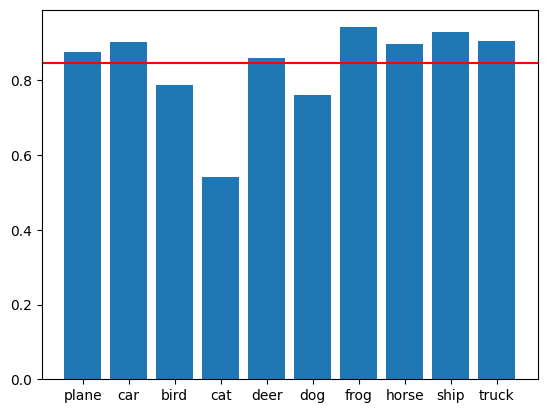

In [17]:
class_correct = [0] * 10 #tracking accuracy for each of the 10 classes
class_total = [0] * 10
model.eval()
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    for i in range(len(labels)):
      label = labels[i].item()
      class_correct[label] += (predicted[i] == labels[i]).item()
      class_total[label] += 1

  for i in range(10):
    acc = class_correct[i] / class_total[i] #calculating accuracy
    print(f"{classes[i]}: {acc} ({int(class_correct[i])} / {class_total[i]})")

  class_accs = [class_correct[i]/class_total[i] for i in range(10)]
  # list of all acuracy used for plotting
  plt.figure()
  bars = plt.bar(classes, class_accs)
  plt.axhline(best_acc, color = 'red') #draws a reference line


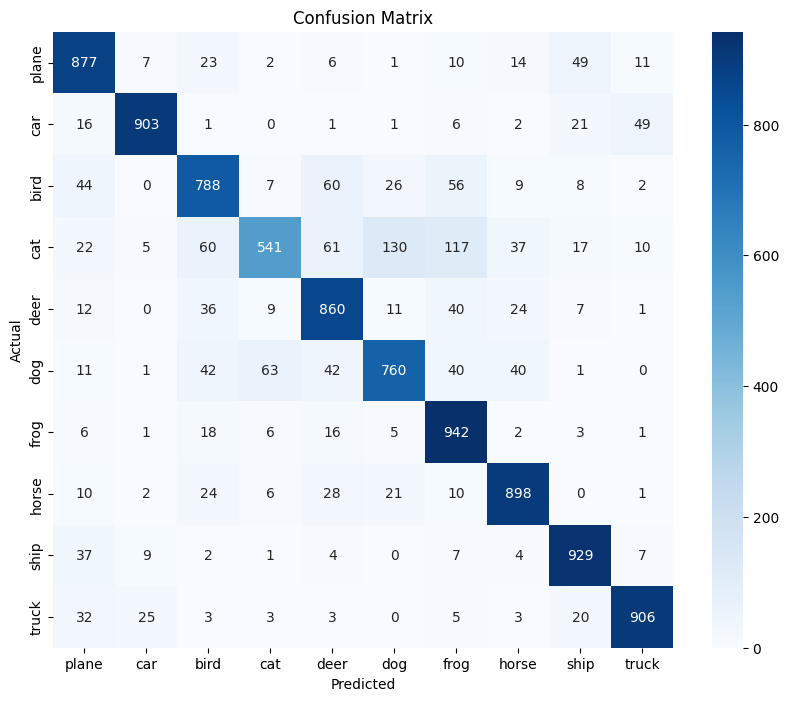

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = [] #list to gather results across test set
all_labels = []

model.eval() #turning off dropout
with torch.no_grad(): # don't track gradients, saves memory
    for images, labels in test_loader: #go through all test batches
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1) #get predicted class per image
        all_preds.extend(predicted.cpu().numpy())
        #.cpu() moves tensor from GPU back to CPU (required before converting to numpy)
        #.numpy() converts PyTorch tensor to numpy array
        all_labels.extend(labels.numpy()) # adds all 128 numbers individually

cm = confusion_matrix(all_labels, all_preds) #produces a 10x10 grid
plt.figure(figsize=(10, 8))
# seaborn is built on matplotlib. help draw heatmaps easily
# creates a colored grid
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
# fmt='d' Format the numbers as integers
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

annot = True in seaborn replaces in plt
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', ...)

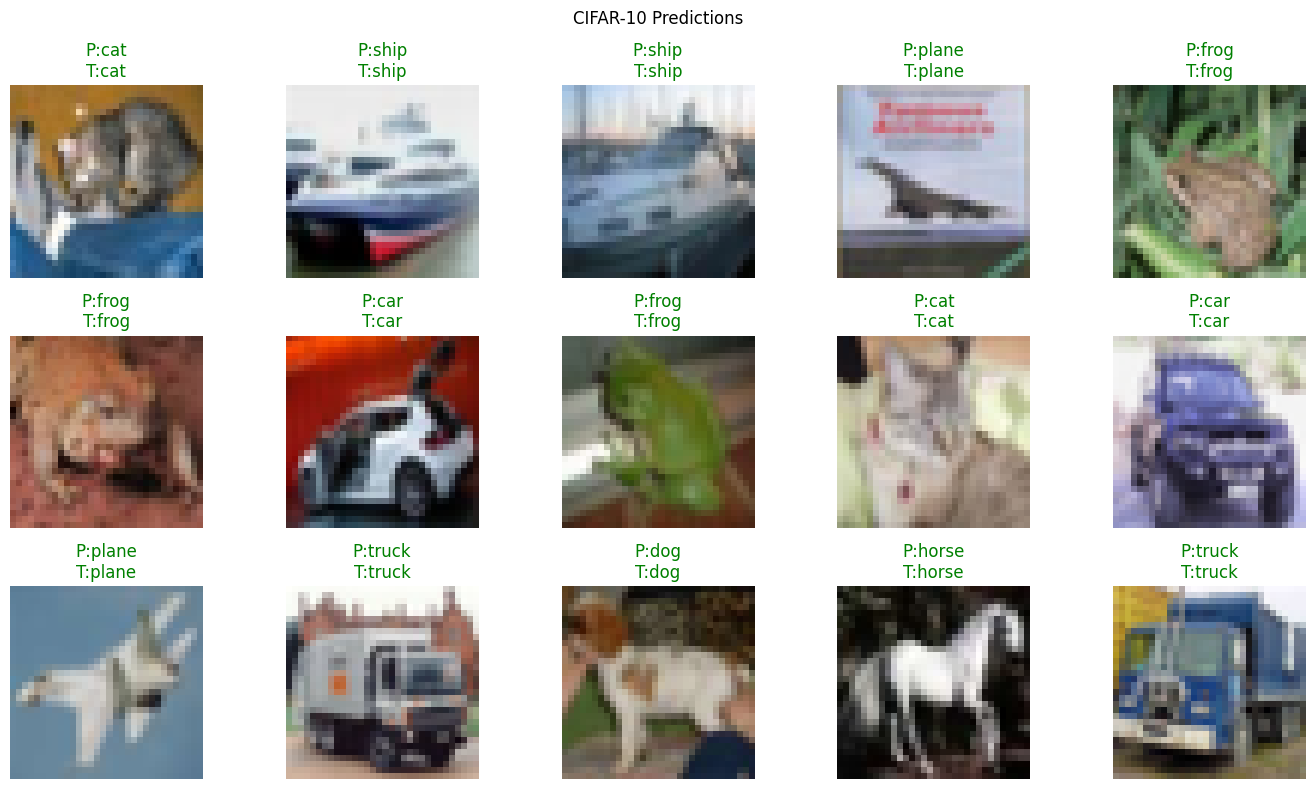

In [34]:
view_loader = torch.utils.data.DataLoader(test_dataset, batch_size= 15, shuffle = True)


def show_predictions():
    images, labels = next(iter(test_loader))
    images_device = images.to(device)

    with torch.no_grad():
        outputs = model(images_device)
        _, predicted = torch.max(outputs, 1)

    fig, axes = plt.subplots(3, 5, figsize=(14, 8))
    for i, ax in enumerate(axes.flatten()):
        img = images[i].numpy().transpose(1, 2, 0)
        img = (img * 0.5) + 0.5
        ax.imshow(img)
        color = 'green' if predicted[i].cpu() == labels[i] else 'red'
        ax.set_title(f"P:{classes[predicted[i].cpu()]}\nT:{classes[labels[i]]}", color=color)
        ax.axis('off')
    plt.suptitle("CIFAR-10 Predictions")
    plt.tight_layout()
    plt.show()

show_predictions()  # call this each time for a new random batch

cats are consistently the hardest class across almost every model